In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from urllib.parse import quote

In [141]:


base = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query={}&format=csv"

query = """
select
    pl_name,
    sy_name,
    hostname,
    discoverymethod,
    pl_bmassj,
    pl_orbsmax,
    pl_orbper,
    pl_rade,
    cb_flag,
    disc_year
from pscomppars
where
    cb_flag = 1
"""

df_planets = pd.read_csv(base.format(quote(query)))

In [142]:
host_names = ['Kepler-16',
 'Kepler-34',
 'Kepler-35',
 'Kepler-38',
 'Kepler-47',
 'PH1',
 'Kepler-413',
 'Kepler-453',
 'Kepler-1647',
 'Kepler-1661',
 'TOI-1338',
 'TIC 172900988']

In [144]:
df_planets = (
    df_planets[df_planets["sy_name"].isin(host_names)]
    .reset_index(drop=True)
)
df_planets = df_planets.sort_values(['disc_year','pl_name'])
df_planets

,pl_name,sy_name,hostname,discoverymethod,pl_bmassj,pl_orbsmax,pl_orbper,pl_rade,cb_flag,disc_year
0,Kepler-16 b,Kepler-16,Kepler-16,Transit,0.333000,0.70480,228.7760,8.4493,1,2011
1,Kepler-34 b,Kepler-34,Kepler-34,Transit,0.220000,1.08960,288.8220,8.5640,1,2011
2,Kepler-35 b,Kepler-35,Kepler-35,Transit,0.127000,0.60347,131.4580,8.1600,1,2011
3,Kepler-38 b,Kepler-38,Kepler-38,Transit,0.384000,0.46320,105.5990,4.3000,1,2012
4,Kepler-47 b,Kepler-47,Kepler-47,Transit,0.006513,0.28770,49.4643,3.0500,1,2012
5,Kepler-47 c,Kepler-47,Kepler-47,Transit,0.009974,0.96380,303.2270,4.6500,1,2012
6,PH1 b,PH1,PH1,Transit,0.531000,0.65200,138.3170,6.1800,1,2012
7,Kepler-413 b,Kepler-413,Kepler-413,Transit,0.211000,0.35530,66.2620,4.3470,1,2014
8,Kepler-453 b,Kepler-453,Kepler-453,Transit,0.050341,0.79030,240.5030,6.2040,1,2015
9,Kepler-1647 b,Kepler-1647,Kepler-1647,Transit,1.519680,2.72050,1107.5923,11.8739,1,2016


In [145]:
host_names = ['Kepler-16',
 'Kepler-34',
 'Kepler-35',
 'Kepler-38',
 'Kepler-47',
 'PH1',
 'Kepler-413',
 'Kepler-453',
 'Kepler-1647',
 'Kepler-1661',
 'TOI-1338',
 'TIC 172900988']

In [146]:
host_label = ['Kepler-16',
 'Kepler-34',
 'Kepler-35',
 'Kepler-38',
 'Kepler-47',
 'Kepler-64',
 'Kepler-413',
 'Kepler-453',
 'Kepler-1647',
 'Kepler-1661',
 'TOI-1338',
 'TIC172900988']

In [147]:
orb = []
mass1 = []
mass2 = []
rad1 = []
rad2 = []
teff1 = []
teff2 = []

#Kepler-16 https://www.science.org/doi/epdf/10.1126/science.1210923
orb.append(41.08)

mass1.append(0.6897)
rad1.append(0.6489)
teff1.append(4450)

mass2.append(0.20255)
rad2.append(0.22623)
teff2.append(3110)   #from mamajek


#Kepler-34  https://ui.adsabs.harvard.edu/abs/2012Natur.481..475W/abstract
orb.append(27.79)

mass1.append(1.0479)
rad1.append(1.1618)
teff1.append(5913)  

mass2.append(1.0208)
rad2.append(1.0927)
teff2.append(5867)  


#Kepler-35 https://ui.adsabs.harvard.edu/abs/2012Natur.481..475W/abstract
orb.append(20.73)

mass1.append(0.8877)
rad1.append(1.0284)
teff1.append(5606)

mass2.append(0.8094)
rad2.append(0.7861)
teff2.append(5202)

#Kepler-38 https://ui.adsabs.harvard.edu/abs/2012ApJ...758...87O/abstract
orb.append(18.8)

mass1.append(0.949)
rad1.append(1.757)
teff1.append(5623)

mass2.append(0.249)
rad2.append(0.2724)
teff2.append(3210) #from mamajek

#Kepler-47 https://iopscience.iop.org/article/10.3847/1538-3881/ab0ca0
orb.append(7.448)

mass1.append(0.957)
rad1.append(0.936)
teff1.append(5600) #from mamajek

mass2.append(0.342)
rad2.append(0.338)
teff2.append(3300) #from mamajek


#Kepler-64 (PH1) https://iopscience.iop.org/article/10.1088/0004-637X/768/2/127/pdf
orb.append(20.0)

mass1.append(1.528)
rad1.append(1.734)
teff1.append(6407)

mass2.append(0.378)
rad2.append(0.408)
teff2.append(3561)


#Kepler-413 https://iopscience.iop.org/article/10.1088/0004-637X/784/1/14/pdf
orb.append(10.116)

mass1.append(0.820)
rad1.append(0.7761)
teff1.append(4700)

mass2.append(0.5423)
rad2.append(0.484)
teff2.append(3620) #from mamajek


#Kepler-453
orb.append(27.32)

mass1.append(0.944)
rad1.append(0.833)
teff1.append(5527)

mass2.append(0.1951)
rad2.append(0.2150)
teff2.append(3226)

#Kepler-1647 https://iopscience.iop.org/article/10.3847/0004-637X/827/1/86
orb.append(11.258)

mass1.append(1.2207)
rad1.append(1.7903)
teff1.append(6210)

mass2.append(0.9678)
rad2.append(0.9663)
teff2.append(5770)


#Kepler-1661　https://iopscience.iop.org/article/10.3847/1538-3881/ab665b/pdf
orb.append(28.162)

mass1.append(0.841)
rad1.append(0.762)
teff1.append(5100)

mass2.append(0.262)
rad2.append(0.276)
teff2.append(3585)

#TOI-1338 https://iopscience.iop.org/article/10.3847/1538-3881/ab8a48/pdf
orb.append(14.60)

mass1.append(1.038)
rad1.append(1.299)
teff1.append(5990)

mass2.append(0.2974)
rad2.append(0.3015)
teff2.append(3317)

#TIC172900988
orb.append(19.7)

mass1.append(1.2384)
rad1.append(1.3827)
teff1.append(6050)

mass2.append(1.2019)
rad2.append(1.3124)
teff2.append(5983)

In [148]:
df_stars = pd.DataFrame({'sy_name':host_names,'label':host_label,'orbper':orb, 'mass1':mass1,'rad1':rad1,'teff1':teff1,'mass2':mass2,'rad2':rad2,'teff2':teff2})

df_stars=df_stars.sort_values("orbper", ascending=False)
df_stars


,sy_name,label,orbper,mass1,rad1,teff1,mass2,rad2,teff2
0,Kepler-16,Kepler-16,41.080,0.6897,0.6489,4450,0.20255,0.22623,3110
9,Kepler-1661,Kepler-1661,28.162,0.8410,0.7620,5100,0.26200,0.27600,3585
1,Kepler-34,Kepler-34,27.790,1.0479,1.1618,5913,1.02080,1.09270,5867
7,Kepler-453,Kepler-453,27.320,0.9440,0.8330,5527,0.19510,0.21500,3226
2,Kepler-35,Kepler-35,20.730,0.8877,1.0284,5606,0.80940,0.78610,5202
5,PH1,Kepler-64,20.000,1.5280,1.7340,6407,0.37800,0.40800,3561
11,TIC 172900988,TIC172900988,19.700,1.2384,1.3827,6050,1.20190,1.31240,5983
3,Kepler-38,Kepler-38,18.800,0.9490,1.7570,5623,0.24900,0.27240,3210
10,TOI-1338,TOI-1338,14.600,1.0380,1.2990,5990,0.29740,0.30150,3317
8,Kepler-1647,Kepler-1647,11.258,1.2207,1.7903,6210,0.96780,0.96630,5770


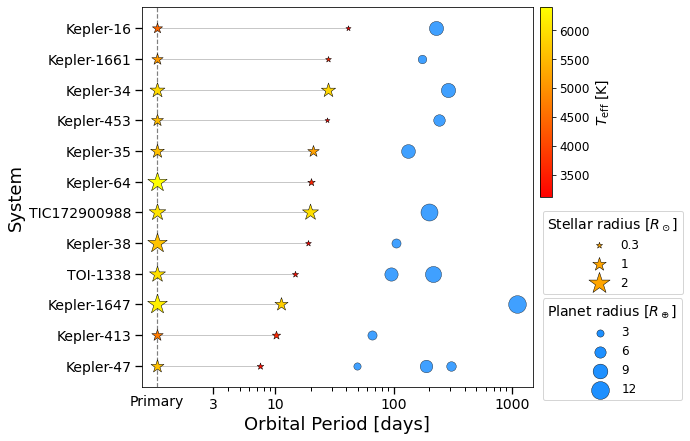

In [149]:
import numpy as np
import matplotlib.pyplot as pl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import LogLocator, NullFormatter,FixedLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---- settings ----
systems = df_stars["sy_name"].values
system_labels = df_stars["label"].values

ypos = np.arange(len(systems))[::-1]
y_map = dict(zip(systems, ypos))

x_A = 1.0
x_min, x_max = 0.75, 1500

# ---- marker size scaling ----
def star_size(r_sun):
    return 200 * r_sun**1.3

def planet_size(r_earth):
    return 12.5 * r_earth**1.3

# ---- color for Teff ----
teff_all = np.r_[df_stars["teff1"].values, df_stars["teff2"].values]
norm = Normalize(vmin=np.nanmin(teff_all), vmax=np.nanmax(teff_all))
cmap = pl.cm.autumn

fig, ax = pl.subplots(figsize=(7, 7,))

# ---- guide for primary stars ----
ax.axvline(x_A, color="0.5", ls="--", lw=1.2, zorder=0)

# ---- stars ----
for _, row in df_stars.iterrows():
    y = y_map[row["sy_name"]]

    # Primary star A: reference position
    ax.scatter(
        x_A, y,
        s=star_size(row["rad1"]),
        c=[cmap(norm(row["teff1"]))],
        marker="*",
        edgecolor="k",
        linewidth=0.5,
        zorder=4,
    )

    # Secondary star B: binary orbital period
    ax.scatter(
        row["orbper"], y,
        s=star_size(row["rad2"]),
        c=[cmap(norm(row["teff2"]))],
        marker="*",
        edgecolor="k",
        linewidth=0.5,
        zorder=4,
    )

    ax.plot([x_A, row["orbper"]], [y, y], color="0.78", lw=1, zorder=1)

# ---- planets ----
for _, row in df_planets.iterrows():
    sy = row["sy_name"]

    if sy == "PH1":
        sy = "Kepler-64"

    if sy not in y_map:
        continue

    ax.scatter(
        row["pl_orbper"], y_map[sy],
        s=planet_size(row["pl_rade"]),
        color="dodgerblue",
        edgecolor="k",
        linewidth=0.4,
        alpha=0.85,
        zorder=5,
    )

# ---- axes ----
ax.set_xscale("log")
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.7, len(systems) - 0.3)

ax.set_yticks(ypos)
ax.set_yticklabels(system_labels, fontsize=14)

# No tick at Primary
ax.set_xticks([3, 10, 100, 1000])
ax.set_xticklabels(["3","10", "100", "1000"], fontsize=14)

# minor ticks from ~3 days
minor_ticks = []
for decade in [1, 10, 100, 1000]:
    for m in np.arange(2, 10):
        tick = m * decade
        if 3 <= tick <= x_max:
            minor_ticks.append(tick)

ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))
ax.xaxis.set_minor_formatter(NullFormatter())

# Primary label without tick
ax.text(
    x_A, -0.95,
    "Primary",
    ha="center",
    va="top",
    fontsize=14,
)

ax.set_xlabel("Orbital Period [days]", fontsize=18)
ax.set_ylabel("System", fontsize=18)

ax.tick_params(axis="both", which="major", labelsize=14, length=7, width=1.3)
ax.tick_params(axis="x", which="minor", length=4, width=1.0)

ax.grid(False)

# ---- compact colorbar ----
cax = inset_axes(
    ax,
    width="3%",
    height="50%",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.0, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"$T_{\rm eff}$ [K]", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# ---- legends ----
star_radii = [0.3, 1.0, 2.0]
star_handles = [
    ax.scatter(
        [], [], s=star_size(r), marker="*", color="orange",
        edgecolor="k", linewidth=0.5
    )
    for r in star_radii
]

planet_radii = [3, 6, 9, 12]
planet_handles = [
    ax.scatter(
        [], [], s=planet_size(r), color="dodgerblue",
        edgecolor="k", linewidth=0.4
    )
    for r in planet_radii
]

leg1 = ax.legend(
    star_handles,
    [f"{r:g}" for r in star_radii],
    title=r"Stellar radius [$R_\odot$]",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.48),
    frameon=True,
    fontsize=12,
    title_fontsize=14,
)

ax.add_artist(leg1)

leg2 = ax.legend(
    planet_handles,
    [f"{r:g}" for r in planet_radii],
    title=r"Planet radius [$R_\oplus$]",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.25),
    frameon=True,
    fontsize=12,
    title_fontsize=14,
)

fig.savefig('Output_textbook/circumbinary.pdf', bbox_inches="tight")
#fig.tight_layout()
pl.show()

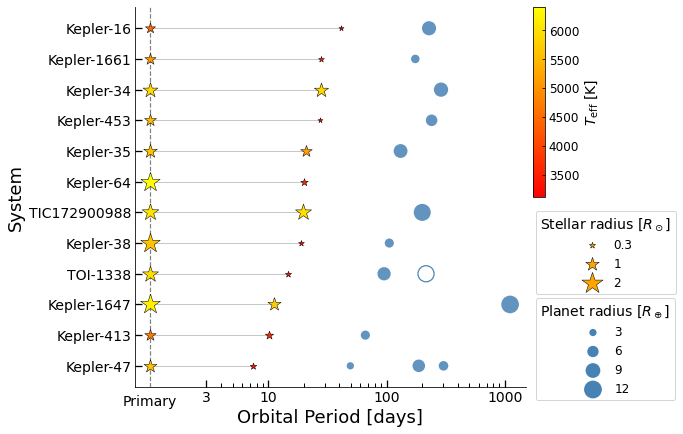

In [150]:
import numpy as np
import matplotlib.pyplot as pl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import NullFormatter, FixedLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ---- settings ----
systems = df_stars["sy_name"].values
system_labels = df_stars["label"].values

ypos = np.arange(len(systems))[::-1]
y_map = dict(zip(systems, ypos))

x_A = 1.0
x_min, x_max = 0.75, 1500

# ---- marker size scaling ----
def star_size(r_sun):
    return 200 * r_sun**1.3

def planet_size(r_earth):
    return 12.5 * r_earth**1.3

# ---- color for Teff ----
teff_all = np.r_[df_stars["teff1"].values, df_stars["teff2"].values]
norm = Normalize(vmin=np.nanmin(teff_all), vmax=np.nanmax(teff_all))
cmap = pl.cm.autumn

fig, ax = pl.subplots(figsize=(7, 7))

# ---- guide for primary stars ----
ax.axvline(x_A, color="0.5", ls="--", lw=1.2, zorder=0)

# ---- stars ----
for _, row in df_stars.iterrows():
    y = y_map[row["sy_name"]]

    ax.scatter(
        x_A, y,
        s=star_size(row["rad1"]),
        c=[cmap(norm(row["teff1"]))],
        marker="*",
        edgecolor="k",
        linewidth=0.5,
        zorder=4,
    )

    ax.scatter(
        row["orbper"], y,
        s=star_size(row["rad2"]),
        c=[cmap(norm(row["teff2"]))],
        marker="*",
        edgecolor="k",
        linewidth=0.5,
        zorder=4,
    )

    ax.plot([x_A, row["orbper"]], [y, y], color="0.78", lw=1, zorder=1)

# ---- planets ----
for _, row in df_planets.iterrows():
    sy = row["sy_name"]

    if sy == "PH1":
        sy = "Kepler-64"

    if sy not in y_map:
        continue

    if row["pl_name"] == "TOI-1338 c":
        facecolor = "none"
        edgecolor = "steelblue"
        linewidth = 1.2
        alpha = 1.0
    else:
        facecolor = "steelblue"
        edgecolor = "none"
        linewidth = 0.0
        alpha = 0.85

    ax.scatter(
        row["pl_orbper"], y_map[sy],
        s=planet_size(row["pl_rade"]),
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=linewidth,
        alpha=alpha,
        zorder=5,
    )

# ---- axes ----
ax.set_xscale("log")
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.7, len(systems) - 0.3)

ax.set_yticks(ypos)
ax.set_yticklabels(system_labels, fontsize=14)

ax.set_xticks([3, 10, 100, 1000])
ax.set_xticklabels(["3", "10", "100", "1000"], fontsize=14)

minor_ticks = []
for decade in [1, 10, 100, 1000]:
    for m in np.arange(2, 10):
        tick = m * decade
        if 3 <= tick <= x_max:
            minor_ticks.append(tick)

ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))
ax.xaxis.set_minor_formatter(NullFormatter())

ax.text(
    x_A, -0.95,
    "Primary",
    ha="center",
    va="top",
    fontsize=14,
)

ax.set_xlabel("Orbital Period [days]", fontsize=18)
ax.set_ylabel("System", fontsize=18)

# tick inward
ax.tick_params(axis="both", which="major", direction="in",
               labelsize=14, length=7, width=1.3)
ax.tick_params(axis="both", which="minor", direction="in",
               length=4, width=1.0)

# remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

# ---- compact colorbar ----
cax = inset_axes(
    ax,
    width="3%",
    height="50%",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.0, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"$T_{\rm eff}$ [K]", fontsize=14)
cbar.ax.tick_params(labelsize=12, direction="in")

# ---- legends ----
star_radii = [0.3, 1.0, 2.0]
star_handles = [
    ax.scatter(
        [], [], s=star_size(r), marker="*", color="orange",
        edgecolor="k", linewidth=0.5
    )
    for r in star_radii
]

planet_radii = [3, 6, 9, 12]
planet_handles = [
    ax.scatter(
        [], [], s=planet_size(r), facecolor="steelblue",
        edgecolor="none", linewidth=0.0
    )
    for r in planet_radii
]

leg1 = ax.legend(
    star_handles,
    [f"{r:g}" for r in star_radii],
    title=r"Stellar radius [$R_\odot$]",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.48),
    frameon=True,
    fontsize=12,
    title_fontsize=14,
)

ax.add_artist(leg1)

leg2 = ax.legend(
    planet_handles,
    [f"{r:g}" for r in planet_radii],
    title=r"Planet radius [$R_\oplus$]",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.25),
    frameon=True,
    fontsize=12,
    title_fontsize=14,
)

fig.savefig("Output_textbook/circumbinary.pdf", bbox_inches="tight")
pl.show()